### Filtering Service-A Assessment
This notebook evaluates the pre-filled 7-day hourly Filter-A dataset and verifies the reported removal effectiveness.

In [2]:
from pathlib import Path
import pandas as pd

csv_path = Path('../data/filter_a_runs_2026-01-04_to_2026-01-10.csv')
df = pd.read_csv(csv_path)
df['run_started_at_utc'] = pd.to_datetime(df['run_started_at_utc'], utc=True)

window_start = pd.Timestamp('2026-01-04T00:00:00Z')
window_end = pd.Timestamp('2026-01-11T00:00:00Z')
window = df[(df['run_started_at_utc'] >= window_start) & (df['run_started_at_utc'] < window_end)].copy()

expected_hourly_runs = 7 * 24
observed_runs = len(window)
coverage_pct = (observed_runs / expected_hourly_runs) * 100 if expected_hourly_runs else 0

avg_removal = window['removal_rate_pct'].mean()
weighted_removal = (window['total_dropped'].sum() / window['ingested_events'].sum()) * 100
min_removal = window['removal_rate_pct'].min()
max_removal = window['removal_rate_pct'].max()

throughput_mean = window['throughput_events_per_sec'].mean()
throughput_p95 = window['throughput_events_per_sec'].quantile(0.95)

manual_sample_total = int(window['manual_sample_size'].sum())
manual_invalid_rate = (window['manual_confirmed_invalid'].sum() / manual_sample_total) * 100
manual_fp_total = int(window['manual_false_positive'].sum())

summary = pd.DataFrame([
    {
        'window_start_utc': '2026-01-04',
        'window_days': 7,
        'runs_observed': observed_runs,
        'runs_expected_hourly': expected_hourly_runs,
        'coverage_pct': round(coverage_pct, 2),
        'avg_removal_rate_pct': round(avg_removal, 2),
        'weighted_removal_rate_pct': round(weighted_removal, 2),
        'min_removal_rate_pct': round(min_removal, 2),
        'max_removal_rate_pct': round(max_removal, 2),
        'throughput_mean_eps': round(throughput_mean, 2),
        'throughput_p95_eps': round(throughput_p95, 2),
        'manual_invalidity_confirm_rate_pct': round(manual_invalid_rate, 2),
        'manual_false_positive_total': manual_fp_total
    }
])
summary

,window_start_utc,window_days,runs_observed,runs_expected_hourly,coverage_pct,avg_removal_rate_pct,weighted_removal_rate_pct,min_removal_rate_pct,max_removal_rate_pct,throughput_mean_eps,throughput_p95_eps,manual_invalidity_confirm_rate_pct,manual_false_positive_total
0,2026-01-04,7,168,168,100.0,21.74,21.76,18.08,25.0,333.8,623.55,100.0,0


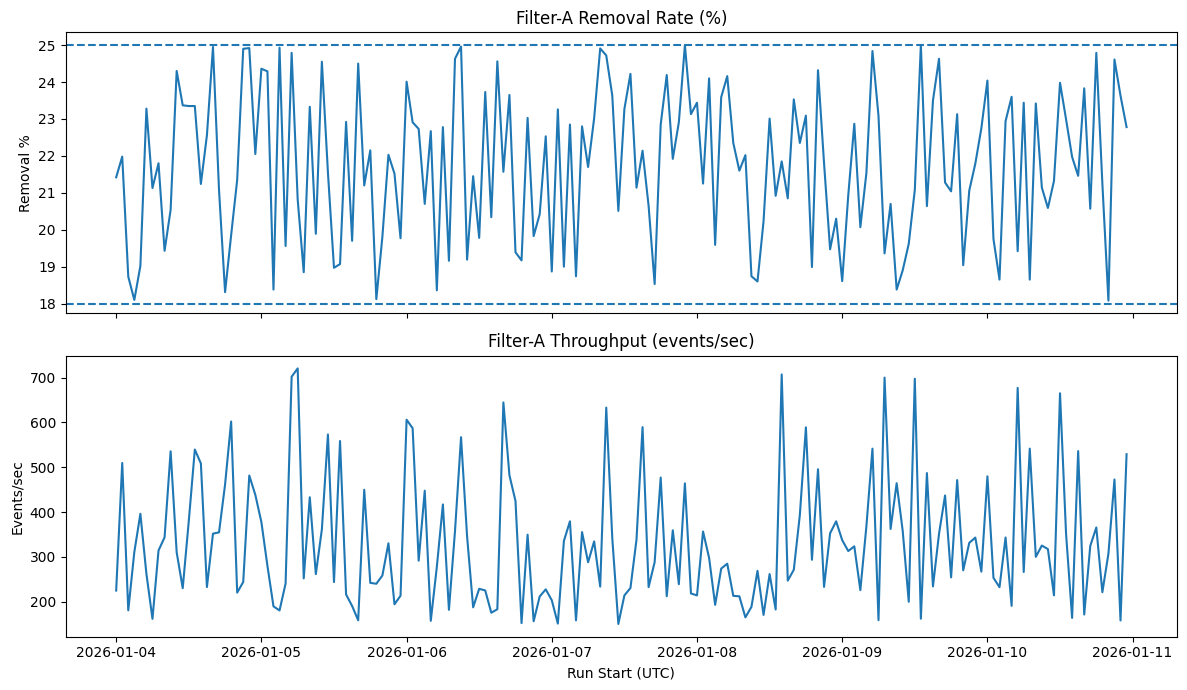

In [3]:
import matplotlib.pyplot as plt

plot_df = window.sort_values('run_started_at_utc').copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(plot_df['run_started_at_utc'], plot_df['removal_rate_pct'])
axes[0].axhline(18, linestyle='--')
axes[0].axhline(25, linestyle='--')
axes[0].set_title('Filter-A Removal Rate (%)')
axes[0].set_ylabel('Removal %')

axes[1].plot(plot_df['run_started_at_utc'], plot_df['throughput_events_per_sec'])
axes[1].set_title('Filter-A Throughput (events/sec)')
axes[1].set_ylabel('Events/sec')
axes[1].set_xlabel('Run Start (UTC)')

plt.tight_layout()
plt.show()